In [203]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [204]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [206]:
product_df = pd.read_csv(r"C:\Users\jindo\PycharmProjects\PythonProject2\product_level_table.csv")

In [207]:
print("Preview:")
display(product_df.head())

print("Info:")
display(product_df.info())

Preview:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",0.64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,0.43,4.0,43994.0,"Compatible with all Type C enabled devices, be...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",0.90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,0.53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,0.61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Info:
<class 'pandas.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1348 non-null   str    
 1   product_name         1348 non-null   str    
 2   category             1348 non-null   str    
 3   discounted_price     1348 non-null   str    
 4   actual_price         1348 non-null   str    
 5   discount_percentage  1348 non-null   float64
 6   rating               1348 non-null   float64
 7   rating_count         1348 non-null   float64
 8   about_product        1348 non-null   str    
 9   img_link             1348 non-null   str    
 10  product_link         1348 non-null   str    
dtypes: float64(3), str(8)
memory usage: 116.0 KB


None

In [208]:
print("Total products:" , product_df["product_id"].nunique())
print("Total categories:", product_df["category"].nunique())

print("\nDescriptive statistic: ")
display(product_df[[
    "rating",
    "rating_count",
    "discount_percentage",
    "discounted_price",
    "actual_price"
]].describe())

Total products: 1348
Total categories: 211

Descriptive statistic: 


,rating,rating_count,discount_percentage
count,1348.000000,1348.000000,1348.000000
mean,4.091988,17656.847923,0.466625
std,0.295139,42158.843602,0.216077
min,2.000000,2.000000,0.000000
25%,3.900000,1107.500000,0.310000
50%,4.100000,4740.000000,0.490000
75%,4.300000,16051.500000,0.620000
max,5.000000,426973.000000,0.940000


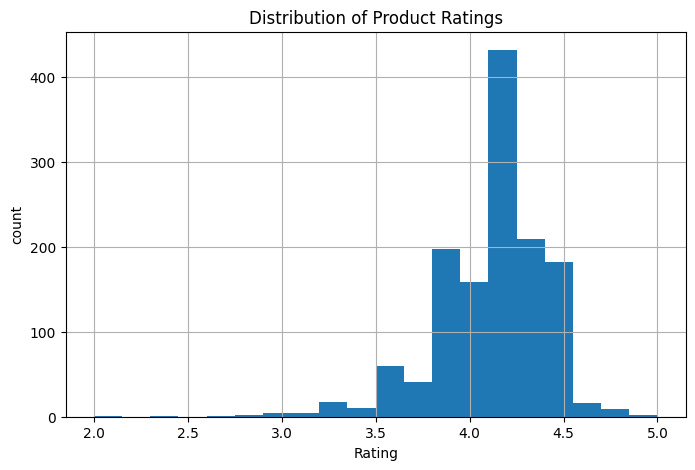

In [209]:
plt.figure(figsize = (8,5))
product_df["rating"].dropna().hist(bins = 20)
plt.title("Distribution of Product Ratings")
plt.ylabel("count")
plt.xlabel("Rating")
plt.show()

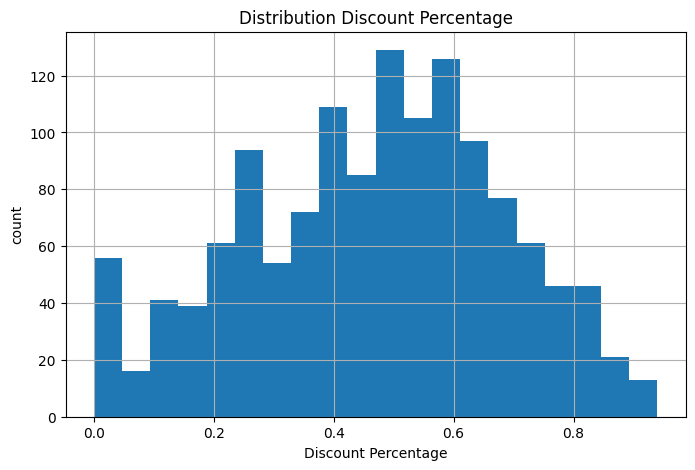

In [210]:
plt.figure(figsize = (8,5))
product_df["discount_percentage"].dropna().hist(bins = 20)
plt.title("Distribution Discount Percentage")
plt.ylabel("count")
plt.xlabel("Discount Percentage")
plt.show()

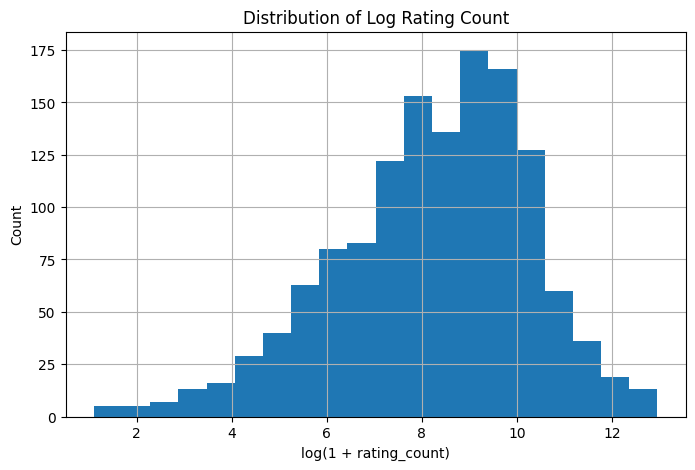

In [211]:
product_df["log_rating_count"] = np.log1p(product_df["rating_count"]).round(2)

plt.figure(figsize = (8,5))
product_df["log_rating_count"].dropna().hist(bins = 20)
plt.title("Distribution of Log Rating Count")
plt.xlabel("log(1 + rating_count)")
plt.ylabel("Count")
plt.show()



In [212]:
print(product_df["actual_price"].info())

<class 'pandas.Series'>
RangeIndex: 1348 entries, 0 to 1347
Series name: actual_price
Non-Null Count  Dtype
--------------  -----
1348 non-null   str  
dtypes: str(1)
memory usage: 10.7 KB
None


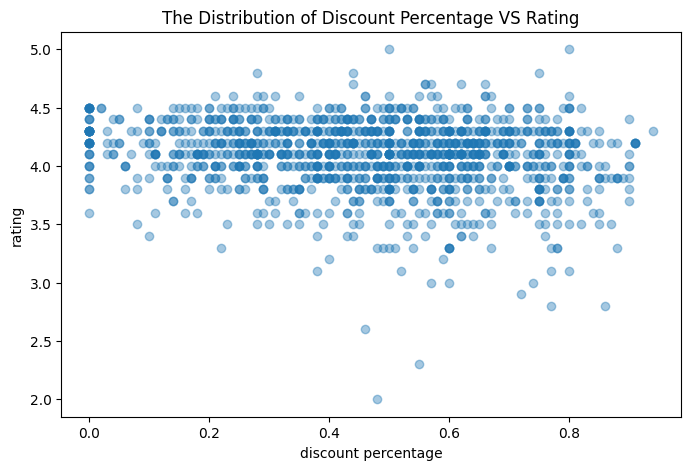

In [213]:
plt.figure(figsize = (8,5))
plt.scatter(product_df["discount_percentage"], product_df["rating"], alpha = 0.4)
plt.title("The Distribution of Discount Percentage VS Rating") 
plt.xlabel("discount percentage")
plt.ylabel("rating")
plt.show()

In [214]:
product_df["rating"] = pd.to_numeric(product_df["rating"], errors = "coerce")
product_df["discount_percentage"] = pd.to_numeric(product_df["discount_percentage"], errors = "coerce")
product_df["rating_count"] = pd.to_numeric(product_df["rating_count"], errors = "coerce")

product_df["discounted_price"] = (
    product_df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex = False)
    .str.replace(",", "", regex = False)
)
product_df["discounted_price"] = pd.to_numeric(product_df["discounted_price"], errors = "coerce")


category_summary = product_df.groupby(product_df["category"]).agg(
    product_count = ("product_id" , "nunique"),
    avg_rating = ("rating" , "mean"),
    avg_rating_count = ("rating_count", "mean"),
    avg_discount = ("discount_percentage", "mean"),
    avg_discounted_price = ("discounted_price", "mean")
).reset_index().round(2)

category_summary = category_summary.sort_values("product_count", ascending = False)

display(category_summary.head(40))


,category,product_count,avg_rating,avg_rating_count,avg_discount,avg_discounted_price
10,Computers&Accessories|Accessories&Peripherals|...,159,4.15,13972.77,0.60,379.94
117,Electronics|Mobiles&Accessories|Smartphones&Ba...,68,4.10,36665.72,0.23,15754.44
119,Electronics|WearableTechnology|SmartWatches,62,4.01,19805.77,0.70,2363.44
97,"Electronics|HomeTheater,TV&Video|Televisions|S...",60,4.21,11446.12,0.38,25399.22
76,"Electronics|Headphones,Earbuds&Accessories|Hea...",51,3.89,78673.57,0.59,983.57
93,"Electronics|HomeTheater,TV&Video|Accessories|R...",49,3.80,703.78,0.60,438.94
169,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,27,4.01,11789.67,0.44,3004.72
181,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",24,4.13,10771.33,0.34,762.17
18,Computers&Accessories|Accessories&Peripherals|...,24,4.29,16970.38,0.42,609.33
140,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",23,4.05,6249.70,0.48,2402.17


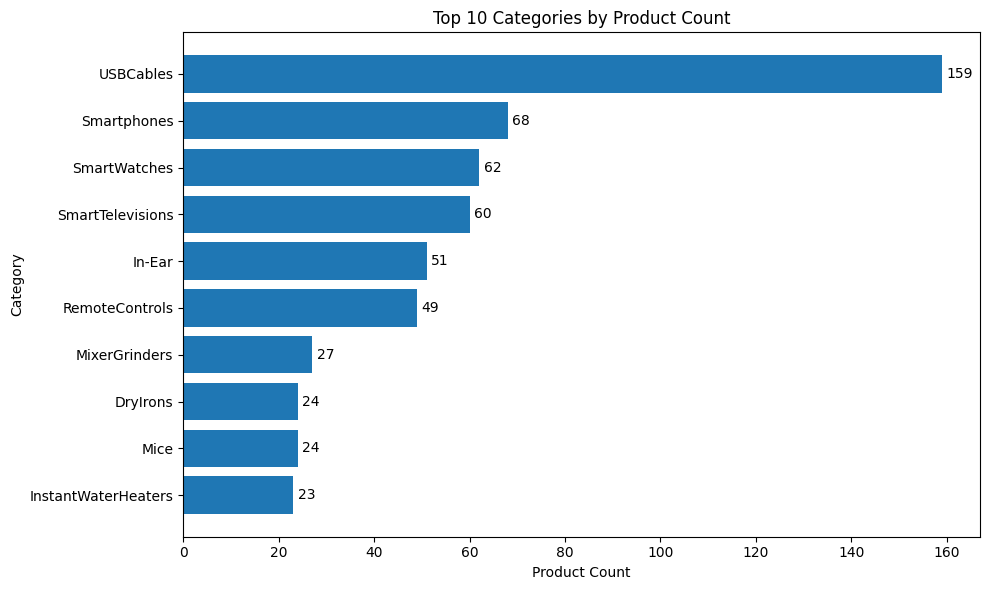

In [215]:
top10 = category_summary.head(10).copy()
top10["short_category"] = top10["category"].str.split("|").str[-1]

plt.figure(figsize=(10, 6))
plt.barh(top10["short_category"], top10["product_count"])
plt.title("Top 10 Categories by Product Count")
plt.xlabel("Product Count")
plt.ylabel("Category")
plt.gca().invert_yaxis()

for i, v in enumerate(top10["product_count"]):
    plt.text(v + 1, i, str(v), va="center")

plt.tight_layout()
plt.show()

In [224]:
product_df["actual_price"] = (
    product_df["actual_price"]
        .astype(str)
        .str.replace("₹", "", regex = False)
        .str.replace(",", "", regex = False)
)

product_df["discounted_price"] = (
    product_df["discounted_price"]
        .astype(str)
        .str.replace("₹", "", regex = False)
        .str.replace(",", "", regex = False)
)


product_df["actual_price"] = pd.to_numeric(product_df["actual_price"], errors = "coerce")
product_df["discounted_price"] = pd.to_numeric(product_df["discounted_price"], errors = "coerce")


product_df["price_gap"] = product_df["actual_price"] - product_df["discounted_price"]

product_df["discount_ratio_calc"] = (
    product_df["price_gap"] / product_df["actual_price"]
)* 100 
product_df["discount_ratio_calc"] = product_df["discount_ratio_calc"].round(2)

In [225]:
product_df["review_strength"] = (
    product_df["rating"] * np.log1p(product_df["rating_count"])
).round(2)

product_df["discount_efficiency_score"] = (
    product_df["rating"] * np.log1p(product_df["rating_count"])
    / (1 + product_df["discount_percentage"])
).round(2)

In [226]:
features = product_df[[
    "rating",
    "log_rating_count",
    "discount_percentage"
]].fillna(0)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

product_df["rating_norm"] = scaled[:,0].round(2)
product_df["log_rating_count_norm"] = scaled[:, 1].round(2)
product_df["discount_norm"] = scaled[:, 2].round(2)

In [227]:

product_df["product_performance_score"] = (
    0.45 * product_df["rating_norm"] +
    0.35 * product_df["log_rating_count_norm"] +
    0.20 * product_df["discount_norm"]
).round(2)

display(product_df[[
    "product_name",
    "rating",
    "rating_count",
    "discount_percentage",
    "product_performance_score"
]].sort_values("product_performance_score", ascending=False).head(10))

,product_name,rating,rating_count,discount_percentage,product_performance_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,0.78,0.88
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,0.69,0.86
40,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,4.5,107687.0,0.70,0.83
30,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,4.5,74976.0,0.73,0.83
390,Samsung EVO Plus 128GB microSDXC UHS-I U3 130M...,4.3,140036.0,0.71,0.82
457,ELV Aluminum Adjustable Mobile Phone Foldable ...,4.5,28978.0,0.82,0.82
408,Samsung EVO Plus 64GB microSDXC UHS-I U1 130MB...,4.3,140036.0,0.68,0.81
513,"SanDisk Ultra microSD UHS-I Card 64GB, 120MB/s R",4.4,67260.0,0.73,0.81
551,Elv Aluminium Adjustable Mobile Phone Foldable...,4.5,28978.0,0.79,0.81
557,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0,0.56,0.80


In [228]:
def classify_product(row):
    if row["rating"] >= 4.2 and row["rating_count"] >= 1000:
        return "Stars"
    elif row["rating"] >= 4.2 and row["rating_count"] < 1000:
        return "Hidden Gems"
    elif row["discount_percentage"] >= 50 and row["rating"] < 4.0:
        return "Discount-Dependent"
    elif row["rating"] < 3.8 and row["rating_count"] >= 500:
        return "At-Risk"
    else:
        return "Mid-Tier"

product_df["product_segment"] = product_df.apply(classify_product, axis=1)

display(product_df[[
    "product_name",
    "rating",
    "rating_count",
    "discount_percentage",
    "product_segment"
]].head(10))

,product_name,rating,rating_count,discount_percentage,product_segment
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,24269.0,0.64,Stars
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,43994.0,0.43,Mid-Tier
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,7928.0,0.90,Mid-Tier
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,94363.0,0.53,Stars
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,16905.0,0.61,Stars
5,pTron Solero TB301 3A Type-C Data and Fast Cha...,3.9,24871.0,0.85,Mid-Tier
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",4.1,15188.0,0.65,Mid-Tier
7,MI Usb Type-C Cable Smartphone (Black),4.3,30411.0,0.23,Stars
8,"TP-Link USB WiFi Adapter for PC(TL-WN725N), N1...",4.2,179691.0,0.50,Stars
9,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,43994.0,0.33,Mid-Tier


In [229]:
product_df["rating"] = pd.to_numeric(product_df["rating"], errors = "coerce")
product_df["discount_percentage"] = pd.to_numeric(product_df["discount_percentage"], errors = "coerce")
product_df["rating_count"] = pd.to_numeric(product_df["rating_count"], errors = "coerce")
product_df["discounted_price"] = pd.to_numeric(product_df["discounted_price"], errors = "coerce")


segment_summary = product_df.groupby("product_segment").agg(
    product_count=("product_id", "count"),
    avg_rating=("rating", "mean"),
    avg_rating_count=("rating_count", "mean"),
    avg_discount=("discount_percentage", "mean"),
    avg_score=("product_performance_score", "mean")
).reset_index().round(2)

display(segment_summary)

,product_segment,product_count,avg_rating,avg_rating_count,avg_discount,avg_score
0,At-Risk,83,3.54,8022.13,0.54,0.56
1,Hidden Gems,109,4.35,356.22,0.52,0.59
2,Mid-Tier,640,3.94,17438.07,0.48,0.60
3,Stars,516,4.32,23132.56,0.42,0.68


In [230]:
product_df.to_csv("product_level_socred.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)

print("Files saved:")
print("- product_level_scored.csv")
print("- category_summary.csv")
print("- segment_summary.csv")

Files saved:
- product_level_scored.csv
- category_summary.csv
- segment_summary.csv
